# One-body densities

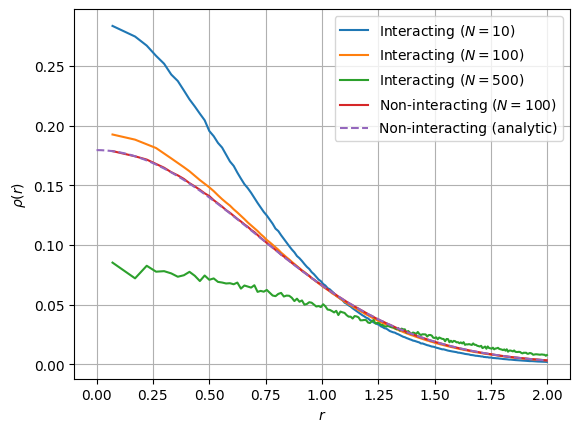

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

from vmc_jax import MetropolisJAX
from bose_harmonic_jax import (
  log_wavefunction_jax as log_wavefunction_harmonic,
  local_energy_jax as local_energy_harmonic,
  drift_force_jax as drift_force_harmonic,
  HarmonicParams,
)
from bose_harmonic import radial_onebody_density
from bose_repulsive_jax import (
  log_wavefunction_jax as log_wavefunction_repulsive,
  local_energy_jax as local_energy_repulsive,
  drift_force_jax as drift_force_repulsive,
  BoseParams,
)
from density import radial_density

base_cycles = 1_000_000
base_dt = 0.1
diffusion_coefficient = 0.5
max_radius = 2.0
bins = 200
bin_scale = 0.5

number_particles = 100
dim = 3

beta_value = jnp.array(2.82843)
a_value = jnp.array(0.0043)

alpha_values = {
  "harmonic": {
    10: 0.5015940070152283,
    100: 0.5015779733657837,
    500: 0.5011541843414307,
  },
  "repulsive": {
    10: 0.49509719014167786,
    100: 0.44620391726493835,
    500: 0.3759932816028595,
  },
}


# Repulsive bose gas
for n in [10, 100, 500]:
  simulation_repulsive = MetropolisJAX[BoseParams](n, dim)
  params_repulsive = BoseParams(
    alpha=jnp.array(alpha_values["repulsive"][n]),
    beta=beta_value,
    gamma=beta_value,
    a=a_value,
  )

  _, _, _, _, positions_repulsive = simulation_repulsive.sample_importance(
    log_wavefunction_repulsive,
    local_energy_repulsive,
    drift_force_repulsive,
    params_repulsive,
    base_dt,
    diffusion_coefficient,
    base_cycles,
  )

  r_repulsive, density_repulsive = radial_density(
    positions_repulsive, max_radius, bins, bin_scale
  )
  plt.plot(r_repulsive, density_repulsive, label=rf"Interacting ($N={n}$)")


# Harmonic oscillator
simulation_harmonic = MetropolisJAX[HarmonicParams](number_particles, dim)
params_harmonic = HarmonicParams(
  alpha=jnp.array(alpha_values["harmonic"][number_particles])
)

_, _, _, _, positions_harmonic = simulation_harmonic.sample_importance(
  log_wavefunction_harmonic,
  local_energy_harmonic,
  drift_force_harmonic,
  params_harmonic,
  base_dt,
  diffusion_coefficient,
  base_cycles,
)

r_harmonic, density_harmonic = radial_density(
  positions_harmonic, max_radius, bins, bin_scale
)
plt.plot(
  r_harmonic, density_harmonic, label=rf"Non-interacting ($N={number_particles}$)"
)


# Analytic
r = np.linspace(0.0, max_radius, bins)
plt.plot(
  r, radial_onebody_density(r), label="Non-interacting (analytic)", linestyle="dashed"
)

plt.xlabel(r"$r$")
plt.ylabel(r"$\rho(r)$")
plt.legend()
plt.grid(True)
plt.savefig("vmc_bose_onebody_density.pdf", format="pdf")
plt.show()
